In [1]:
try:
    import mpmath  # noqa: F401
except ImportError:
    import sys, subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "mpmath"], check=True)

import importlib
import I2EM, utils
importlib.reload(utils)
importlib.reload(I2EM)
from I2EM import backscatter
print("I2EM module loaded OK")

I2EM module loaded OK


## 2. Quick correctness/timing check


In [2]:
import time
import numpy as np

t0 = time.time()
out_copol = backscatter(0.435, 0.01, 0.06, 35.0, complex(6.0, -1.0), "exponential", 1.5, block_crosspol=True)
t_copol = time.time() - t0
print(f"HH+VV only: {out_copol} -- {t_copol:.4f} s")

t0 = time.time()
out_full = backscatter(0.435, 0.01, 0.06, 35.0, complex(6.0, -1.0), "exponential", 1.5, block_crosspol=False)
t_full = time.time() - t0
print(f"HH+VV+HV:   {out_full} -- {t_full:.2f} s  (HV alone cost ~{t_full - t_copol:.2f} s)")

HH+VV only: (-25.504987231020586, -28.890067730058355, nan) -- 0.0181 s
HH+VV+HV:   (-25.504987231020586, -28.890067730058355, -65.20031634049582) -- 34.84 s  (HV alone cost ~34.82 s)


## 3. LUT generator


In [3]:
C0 = 299_792_458.0
BIOMASS_FREQ_GHZ = 0.435       # EDIT if not using BIOMASS P-band
LOSS_TANGENT = 0.15            # EDIT: eps_i = LOSS_TANGENT * eps_r placeholder
CORR_FUNC = "exponential"      # EDIT: "exponential" or "gaussian"
XX = 1.5                       # only used for power_spec correlation function
L_OVER_SIGMA = 6.0             # EDIT: fixed correlation-length / rms-height ratio assumption


def ks_to_sigma_h_m(ks, freq_ghz=BIOMASS_FREQ_GHZ):
    """Convert dimensionless ks to rms height in metres for this frequency."""
    k_per_m = 2.0 * np.pi * freq_ghz * 1e9 / C0
    return ks / k_per_m


def generate_i2em_lut(eps_axis, ks_axis, theta_axis, freq_ghz=BIOMASS_FREQ_GHZ,
                       loss_tangent=LOSS_TANGENT, corr_func=CORR_FUNC, xx=XX,
                       l_over_sigma=L_OVER_SIGMA, include_hv=False, progress_every=200):
    eps_axis = np.asarray(eps_axis, dtype=float)
    ks_axis = np.asarray(ks_axis, dtype=float)
    theta_axis = np.asarray(theta_axis, dtype=float)

    n_eps, n_ks, n_theta = len(eps_axis), len(ks_axis), len(theta_axis)
    n_total = n_eps * n_ks * n_theta

    sigma0_hh = np.full((n_theta, n_ks, n_eps), np.nan)
    sigma0_vv = np.full((n_theta, n_ks, n_eps), np.nan)
    sigma0_hv = np.full((n_theta, n_ks, n_eps), np.nan) if include_hv else None

    est_time = n_total * (30.0 if include_hv else 0.014)
    print(f"Generating I2EM LUT: {n_theta} theta x {n_ks} ks x {n_eps} eps' "
          f"= {n_total} points. Estimated time: {est_time/60:.1f} min "
          f"({'HV included -- this will be slow' if include_hv else 'HH+VV only'}).")

    t0 = time.time()
    count = 0
    for it, theta in enumerate(theta_axis):
        for ik, ks_val in enumerate(ks_axis):
            sigma_h_m = ks_to_sigma_h_m(ks_val, freq_ghz)
            L_m = l_over_sigma * sigma_h_m
            for ie, eps_r in enumerate(eps_axis):
                eps_i = loss_tangent * eps_r
                er = complex(eps_r, -eps_i)

                vv_db, hh_db, hv_db = backscatter(
                    freq_ghz, sigma_h_m, L_m, float(theta), er, corr_func, xx,
                    block_crosspol=not include_hv,
                )
                sigma0_hh[it, ik, ie] = 10.0 ** (hh_db / 10.0)
                sigma0_vv[it, ik, ie] = 10.0 ** (vv_db / 10.0)
                if include_hv:
                    sigma0_hv[it, ik, ie] = 10.0 ** (hv_db / 10.0)

                count += 1
                if count % progress_every == 0:
                    elapsed = time.time() - t0
                    rate = count / elapsed
                    remaining = (n_total - count) / rate
                    print(f"  {count}/{n_total}  ({elapsed:.0f}s elapsed, ~{remaining/60:.1f} min remaining)")

    print(f"Done in {time.time()-t0:.1f} s.")

    out = {
        "eps_axis": eps_axis, "ks_axis": ks_axis, "theta_axis": theta_axis,
        "sigma0_hh": sigma0_hh, "sigma0_vv": sigma0_vv,
        "freq_ghz": freq_ghz, "loss_tangent": loss_tangent,
        "corr_func": corr_func, "l_over_sigma": l_over_sigma,
        "model": "I2EM (Hsieh et al. 1997, via Ulaby & Long 2014 code) -- NOT full AIEM",
    }
    if include_hv:
        out["sigma0_hv"] = sigma0_hv
    return out


def save_i2em_lut_npz(path, lut_dict):
    np.savez(path, **lut_dict)
    print(f"Saved LUT to {path}")

### Generate the LUT



In [22]:
# Physically defensible main I2EM LUT for thesis retrieval
eps_axis = np.linspace(2.0, 10.0, 140)

ks_axis = 0.046 + (0.5 - 0.046) * (
    np.linspace(0,1,120)**2
)

theta_axis = np.linspace(22.0, 35, 130)

lut_dict = generate_i2em_lut(
    eps_axis,
    ks_axis,
    theta_axis,
    include_hv=False
)

save_i2em_lut_npz("biomass_i2em_main_v9", lut_dict)

Generating I2EM LUT: 130 theta x 120 ks x 140 eps' = 2184000 points. Estimated time: 509.6 min (HH+VV only).
  200/2184000  (2s elapsed, ~346.8 min remaining)
  400/2184000  (4s elapsed, ~349.7 min remaining)
  600/2184000  (6s elapsed, ~365.4 min remaining)
  800/2184000  (8s elapsed, ~370.9 min remaining)
  1000/2184000  (11s elapsed, ~399.2 min remaining)
  1200/2184000  (14s elapsed, ~412.8 min remaining)
  1400/2184000  (16s elapsed, ~423.4 min remaining)
  1600/2184000  (19s elapsed, ~431.4 min remaining)
  1800/2184000  (22s elapsed, ~441.1 min remaining)
  2000/2184000  (25s elapsed, ~447.8 min remaining)
  2200/2184000  (27s elapsed, ~451.4 min remaining)
  2400/2184000  (30s elapsed, ~454.0 min remaining)
  2600/2184000  (33s elapsed, ~458.1 min remaining)
  2800/2184000  (36s elapsed, ~470.6 min remaining)
  3000/2184000  (39s elapsed, ~476.4 min remaining)
  3200/2184000  (43s elapsed, ~483.6 min remaining)
  3400/2184000  (45s elapsed, ~486.0 min remaining)
  3600/2184000 

## 4. Sanity-check the generated LUT



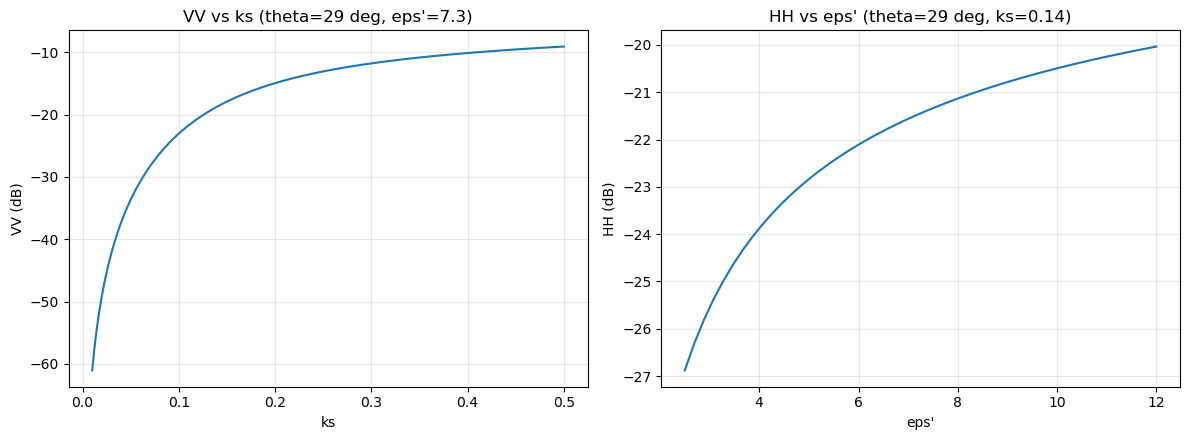

Expect: VV rising then saturating (and possibly rolling over at very high ks -- 
a known I2EM/AIEM behavior beyond their nominal validity range, not a bug).
Expect: HH monotonically rising and saturating with eps'.


In [11]:
import matplotlib.pyplot as plt

hh_db = 10 * np.log10(np.clip(lut_dict["sigma0_hh"], 1e-12, None))
vv_db = 10 * np.log10(np.clip(lut_dict["sigma0_vv"], 1e-12, None))

it_mid = len(theta_axis) // 2
ie_mid = len(eps_axis) // 2
ik_mid = len(ks_axis) // 2

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(ks_axis, vv_db[it_mid, :, ie_mid])
axes[0].set_xlabel("ks"); axes[0].set_ylabel("VV (dB)")
axes[0].set_title(f"VV vs ks (theta={theta_axis[it_mid]:.0f} deg, eps'={eps_axis[ie_mid]:.1f})")
axes[0].grid(alpha=0.3)

axes[1].plot(eps_axis, hh_db[it_mid, ik_mid, :])
axes[1].set_xlabel("eps'"); axes[1].set_ylabel("HH (dB)")
axes[1].set_title(f"HH vs eps' (theta={theta_axis[it_mid]:.0f} deg, ks={ks_axis[ik_mid]:.2f})")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Expect: VV rising then saturating (and possibly rolling over at very high ks -- ")
print("a known I2EM/AIEM behavior beyond their nominal validity range, not a bug).")
print("Expect: HH monotonically rising and saturating with eps'.")